# 🚀 Space Defender - PRO MODE v5: Flexible Positioning
## Fixes "Stuck in Center Getting Surrounded" Behavior

**Problem identified in v4:** Agent stays rigidly in center, gets surrounded by enemies/bullets.

**v5 Philosophy:** "Stay away from edges, roam freely in the middle 70%, and MOVE when surrounded!"

**Key changes from v4:**
- ❌ **Removed** center bonus (no more magnetic pull to center)
- ✅ **Keep** edge penalty (don't hide in corners)
- ✅ **NEW** Surrounded detection (count nearby threats)
- ✅ **NEW** Escape movement bonus (reward moving when in danger)
- ✅ **NEW** Sitting duck penalty (punish staying still when surrounded)

**Expected result:** Agent roams freely in safe zone, actively evades when threatened.

---
## 📌 Step 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
from datetime import datetime

# =========================
# CONFIGURE YOUR PATHS HERE
# =========================
PROJECT_NAME = "Assignment 1 v1 A100 - Zhou Bojian"
BASE_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"

# Load from v4 best model (or your preferred checkpoint)
CHECKPOINT_PATH = f"{BASE_DIR}/finetune_v4_enemy_avoidance_20260117_115918/models/best_avg_model.pth"

# Create output directory for v5
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"{BASE_DIR}/finetune_v5_flexible_position_{TIMESTAMP}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/models", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/videos", exist_ok=True)

print(f"📂 Loading checkpoint from: {CHECKPOINT_PATH}")
print(f"📂 Saving fine-tuned model to: {OUTPUT_DIR}")

# Verify checkpoint exists
if os.path.exists(CHECKPOINT_PATH):
    print("✅ Checkpoint found!")
else:
    print("❌ Checkpoint NOT found! Please check the path.")
    print("   Available v4 folders:")
    for f in os.listdir(BASE_DIR):
        if 'v4' in f or 'finetune' in f:
            print(f"   - {f}")

Mounted at /content/drive
📂 Loading checkpoint from: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_v4_enemy_avoidance_20260117_115918/models/best_avg_model.pth
📂 Saving fine-tuned model to: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_v5_flexible_position_20260117_233606
✅ Checkpoint found!


---
## 📌 Step 2: Install Dependencies

In [ ]:
!pip install pygame -q
!apt-get install -y xvfb ffmpeg > /dev/null 2>&1
!pip install pyvirtualdisplay imageio[ffmpeg] -q
!pip install sympy==1.12.1 --quiet
import numpy as np
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import imageio

print(f"✅ All packages installed!")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 58.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.9.0+cu126 requires sympy>=1.13.3, but you have sympy 1.12.1 which is incompatible.
✅ All packages installed!
PyTorch: 2.9.0+cu126 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB


---
## 📌 Step 3: Configuration

Same stable hyperparameters as v4.

In [ ]:
class Config:
    # Game dimensions
    SCREEN_WIDTH = 600
    SCREEN_HEIGHT = 800

    # Player settings
    PLAYER_WIDTH = 50
    PLAYER_HEIGHT = 40
    PLAYER_SPEED = 8
    PLAYER_BULLET_SPEED = 12
    PLAYER_SHOOT_COOLDOWN = 15
    PLAYER_MAX_HEALTH = 3

    # Enemy settings
    ENEMY_WIDTH = 40
    ENEMY_HEIGHT = 35
    ENEMY_SPEED = 3
    ENEMY_BULLET_SPEED = 6
    ENEMY_SPAWN_RATE = 60
    MAX_ENEMIES = 8
    ENEMY_SHOOT_CHANCE = 0.02

    # Q-Learning hyperparameters (same as v4)
    LEARNING_RATE = 0.00003
    DISCOUNT_FACTOR = 0.99
    EPSILON_START = 0.20         # Slightly lower - v4 model is good
    EPSILON_MIN = 0.05
    EPSILON_DECAY = 0.9998
    BATCH_SIZE = 256
    MEMORY_SIZE = 50000
    TARGET_UPDATE = 150

    # State: 22 features × 4 frames = 88
    STATE_SIZE = 88
    ACTION_SIZE = 6

print("✅ Config loaded (v5 - Flexible Positioning)")
print(f"   Learning Rate: {Config.LEARNING_RATE}")
print(f"   Starting ε: {Config.EPSILON_START}")
print(f"   ε min: {Config.EPSILON_MIN}")

✅ Config loaded (v5 - Flexible Positioning)
   Learning Rate: 3e-05
   Starting ε: 0.2
   ε min: 0.05


---
## 📌 Step 4: Game Objects

In [ ]:
class Player:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self.width, self.height = Config.PLAYER_WIDTH, Config.PLAYER_HEIGHT
        self.speed = Config.PLAYER_SPEED
        self.health = Config.PLAYER_MAX_HEALTH
        self.shoot_cooldown = 0
        self.score = 0
        self.alive = True

    def move(self, direction):
        self.x = max(0, min(self.x + direction * self.speed, Config.SCREEN_WIDTH - self.width))

    def update(self):
        if self.shoot_cooldown > 0: self.shoot_cooldown -= 1

    def can_shoot(self): return self.shoot_cooldown == 0

    def shoot(self):
        self.shoot_cooldown = Config.PLAYER_SHOOT_COOLDOWN
        return Bullet(self.x + self.width // 2 - 3, self.y - 15, -Config.PLAYER_BULLET_SPEED, True)

    def take_damage(self):
        self.health -= 1
        if self.health <= 0: self.alive = False


class Enemy:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self.width, self.height = Config.ENEMY_WIDTH, Config.ENEMY_HEIGHT
        self.speed = Config.ENEMY_SPEED + random.uniform(-1, 1)
        self.health, self.alive = 1, True
        self.direction = random.choice([-1, 0, 1])
        self.change_dir_timer = random.randint(30, 90)

    def update(self):
        self.y += self.speed
        self.x = max(0, min(self.x + self.direction * 2, Config.SCREEN_WIDTH - self.width))
        self.change_dir_timer -= 1
        if self.change_dir_timer <= 0:
            self.direction = random.choice([-1, 0, 1])
            self.change_dir_timer = random.randint(30, 90)
        if self.y > Config.SCREEN_HEIGHT: self.alive = False

    def should_shoot(self): return random.random() < Config.ENEMY_SHOOT_CHANCE

    def shoot(self):
        return Bullet(self.x + self.width // 2 - 3, self.y + self.height, Config.ENEMY_BULLET_SPEED, False)


class Bullet:
    def __init__(self, x, y, speed, is_player_bullet):
        self.x, self.y, self.speed = x, y, speed
        self.width, self.height = 6, 15
        self.is_player_bullet = is_player_bullet
        self.alive = True

    def update(self):
        self.y += self.speed
        if self.y < -self.height or self.y > Config.SCREEN_HEIGHT: self.alive = False

print("✅ Game objects defined!")

✅ Game objects defined!


---
## 📌 Step 5: Neural Network & Replay Memory

In [ ]:
class DQN(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        return self.network(x)


class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        self.memory.append(args)

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

print("✅ DQN and ReplayMemory defined!")

✅ DQN and ReplayMemory defined!


---
## 📌 Step 6: PRO MODE v5 Environment (FLEXIBLE POSITIONING)

**🔴 KEY CHANGES FROM v4:**

| Feature | v4 | v5 |
|---------|-----|-----|
| Center bonus | +0.08 when in center | **REMOVED** |
| Edge penalty | -0.1 at edges | Keep: -0.1 |
| Enemy overhead | -0.2 | **Increased to -0.3** |
| Surrounded detection | None | **NEW: Count nearby threats** |
| Escape bonus | None | **NEW: +0.3 for moving when surrounded** |
| Sitting duck penalty | None | **NEW: -0.4 for staying still when surrounded** |

In [ ]:
class SpaceDefenderEnv:
    """
    PRO MODE v5 Environment - Flexible Positioning

    Philosophy: "Stay away from edges, roam freely in middle 70%,
    and MOVE when surrounded!"
    """

    def __init__(self):
        self.state_buffer = deque(maxlen=4)
        self.last_x = None
        self.stationary_frames = 0
        self.reset()

    def reset(self):
        self.player = Player(
            Config.SCREEN_WIDTH // 2 - Config.PLAYER_WIDTH // 2,
            Config.SCREEN_HEIGHT - 100
        )
        self.enemies = []
        self.player_bullets = []
        self.enemy_bullets = []

        self.frame_count = 0
        self.spawn_timer = 0
        self.game_over = False
        self.enemies_destroyed = 0
        self.survival_time = 0

        # Tracking
        self.last_x = self.player.x
        self.stationary_frames = 0

        initial_frame = self._get_single_frame()
        for _ in range(4):
            self.state_buffer.append(initial_frame)

        return self._get_stacked_state()

    def _get_stacked_state(self):
        return np.concatenate(self.state_buffer)

    def _get_single_frame(self):
        state = []
        state.append(self.player.x / Config.SCREEN_WIDTH)
        state.append(1.0 if self.player.can_shoot() else 0.0)
        state.append(self.player.health / Config.PLAYER_MAX_HEALTH)

        enemies_sorted = sorted(
            self.enemies,
            key=lambda e: abs(e.x - self.player.x) + abs(e.y - self.player.y)
        )[:3]

        for i in range(3):
            if i < len(enemies_sorted):
                enemy = enemies_sorted[i]
                rel_x = (enemy.x - self.player.x) / Config.SCREEN_WIDTH
                rel_y = (enemy.y - self.player.y) / Config.SCREEN_HEIGHT
                threat = 1.0 if abs(enemy.x - self.player.x) < 100 else 0.0
                state.extend([rel_x, rel_y, threat])
            else:
                state.extend([0.0, -1.0, 0.0])

        bullets_sorted = sorted(
            self.enemy_bullets,
            key=lambda b: abs(b.x - self.player.x) + abs(b.y - self.player.y)
        )[:5]

        for i in range(5):
            if i < len(bullets_sorted):
                bullet = bullets_sorted[i]
                rel_x = (bullet.x - self.player.x) / Config.SCREEN_WIDTH
                rel_y = (bullet.y - self.player.y) / Config.SCREEN_HEIGHT
                state.extend([rel_x, rel_y])
            else:
                state.extend([0.0, -1.0])

        return np.array(state, dtype=np.float32)

    def _check_collision(self, obj1, obj2):
        return (obj1.x < obj2.x + obj2.width and
                obj1.x + obj1.width > obj2.x and
                obj1.y < obj2.y + obj2.height and
                obj1.y + obj1.height > obj2.y)

    def step(self, action):
        self.frame_count += 1
        self.survival_time += 1

        # ========== BASE REWARD ==========
        reward = 0.15  # Survival reward

        # Parse action
        move_dir = 0
        should_shoot = False

        if action == 0: move_dir = -1
        elif action == 1: move_dir = 1
        elif action == 2: move_dir = 0
        elif action == 3: should_shoot = True
        elif action == 4: move_dir = -1; should_shoot = True
        elif action == 5: move_dir = 1; should_shoot = True

        # Update player
        old_x = self.player.x
        self.player.move(move_dir)
        self.player.update()

        # Track if player is actually moving
        is_moving = abs(self.player.x - old_x) > 1

        # ========== ANTI-CAMPING (mild) ==========
        if abs(self.player.x - self.last_x) < 5:
            self.stationary_frames += 1
            if self.stationary_frames > 60:  # 1 second of not moving
                reward -= 0.05  # Mild penalty
        else:
            self.stationary_frames = 0
        self.last_x = self.player.x

        # ========== EDGE PENALTY (keep from v4) ==========
        edge_zone = 70  # Slightly smaller edge zone
        if self.player.x < edge_zone or self.player.x > Config.SCREEN_WIDTH - edge_zone:
            reward -= 0.12

        # ================================================================
        # 🔴 v5 CHANGE: NO CENTER BONUS!
        # The agent can roam freely in the middle 70% of the screen
        # We only penalize edges, not reward center
        # ================================================================

        # ================================================================
        # 🔴 v5 NEW: THREAT ASSESSMENT & SURROUNDED DETECTION
        # ================================================================
        player_center_x = self.player.x + self.player.width / 2
        player_top_y = self.player.y

        # Count threats and their positions
        threats_left = 0
        threats_right = 0
        threats_center = 0
        total_threat_level = 0

        # Analyze enemy threats
        for enemy in self.enemies:
            enemy_center_x = enemy.x + enemy.width / 2
            enemy_bottom_y = enemy.y + enemy.height

            dx = player_center_x - enemy_center_x  # Positive = enemy is to the left
            dy = player_top_y - enemy_bottom_y     # Positive = enemy is above
            abs_dx = abs(dx)

            # Only count threats that are above and approaching
            if dy > 0 and dy < 200:
                # Enemy proximity penalty (keep from v4)
                if abs_dx < 70 and dy < 150:
                    proximity_x = 1 - (abs_dx / 70)
                    proximity_y = 1 - (dy / 150)
                    danger_level = proximity_x * proximity_y
                    reward -= 0.5 * danger_level

                # Critical danger zone
                if abs_dx < 50 and dy < 80:
                    reward -= 1.0

                # Imminent collision
                if abs_dx < 40 and dy < 50:
                    reward -= 2.0

                # Track threat direction for surrounded detection
                if abs_dx < 120 and dy < 180:
                    total_threat_level += 1
                    if dx > 40:  # Enemy to the left
                        threats_left += 1
                    elif dx < -40:  # Enemy to the right
                        threats_right += 1
                    else:  # Enemy directly above
                        threats_center += 1

        # Analyze bullet threats
        for bullet in self.enemy_bullets:
            bullet_center_x = bullet.x + bullet.width / 2
            dx = player_center_x - bullet_center_x
            dy = player_top_y - bullet.y
            abs_dx = abs(dx)

            # Bullets that are close and approaching
            if dy > 0 and dy < 150 and abs_dx < 80:
                total_threat_level += 0.5  # Bullets count as half-threat
                if dx > 30:
                    threats_left += 0.5
                elif dx < -30:
                    threats_right += 0.5
                else:
                    threats_center += 0.5

        # ================================================================
        # 🔴 v5 NEW: SURROUNDED DETECTION & ESCAPE REWARD
        # ================================================================
        is_surrounded = (threats_left >= 1 and threats_right >= 1) or \
                        (threats_center >= 1 and total_threat_level >= 2) or \
                        total_threat_level >= 3

        if is_surrounded:
            if is_moving:
                # Good! Agent is trying to escape
                reward += 0.4

                # Extra reward for moving AWAY from higher threat side
                if threats_left > threats_right and move_dir > 0:  # Moving right, away from left threats
                    reward += 0.2
                elif threats_right > threats_left and move_dir < 0:  # Moving left, away from right threats
                    reward += 0.2
            else:
                # Bad! Agent is a sitting duck
                reward -= 0.5

        # ================================================================
        # 🔴 v5 ADJUSTED: Enemy overhead penalty (increased)
        # ================================================================
        if threats_center >= 1:
            reward -= 0.3  # Increased from v4's -0.2

        # ========== SHOOTING ==========
        if should_shoot and self.player.can_shoot():
            self.player_bullets.append(self.player.shoot())
            reward += 0.1

        # ========== SPAWN ENEMIES ==========
        self.spawn_timer += 1
        if self.spawn_timer >= Config.ENEMY_SPAWN_RATE and len(self.enemies) < Config.MAX_ENEMIES:
            self.spawn_timer = 0
            spawn_x = random.randint(0, Config.SCREEN_WIDTH - Config.ENEMY_WIDTH)
            self.enemies.append(Enemy(spawn_x, -Config.ENEMY_HEIGHT))

        # ========== UPDATE ENEMIES ==========
        for enemy in self.enemies[:]:
            enemy.update()
            if enemy.should_shoot():
                self.enemy_bullets.append(enemy.shoot())
            if not enemy.alive:
                self.enemies.remove(enemy)
                reward -= 3.0  # Penalty for letting enemy escape

        # ========== UPDATE BULLETS ==========
        for bullet in self.player_bullets[:]:
            bullet.update()
            if not bullet.alive:
                self.player_bullets.remove(bullet)

        for bullet in self.enemy_bullets[:]:
            bullet.update()
            if not bullet.alive:
                self.enemy_bullets.remove(bullet)

        # ========== PLAYER BULLETS VS ENEMIES ==========
        for bullet in self.player_bullets[:]:
            for enemy in self.enemies[:]:
                if self._check_collision(bullet, enemy):
                    bullet.alive = False
                    enemy.health -= 1
                    reward += 12  # Hit reward

                    if enemy.health <= 0:
                        enemy.alive = False
                        self.enemies.remove(enemy)
                        self.enemies_destroyed += 1
                        self.player.score += 100
                        reward += 60  # Kill reward

                    if bullet in self.player_bullets:
                        self.player_bullets.remove(bullet)
                    break

        # ========== ENEMY BULLETS VS PLAYER ==========
        for bullet in self.enemy_bullets[:]:
            if self._check_collision(bullet, self.player):
                bullet.alive = False
                self.enemy_bullets.remove(bullet)
                self.player.take_damage()
                reward -= 25

                if not self.player.alive:
                    self.game_over = True
                    reward -= 200

        # ========== ENEMY COLLISION WITH PLAYER ==========
        for enemy in self.enemies[:]:
            if self._check_collision(enemy, self.player):
                enemy.alive = False
                self.enemies.remove(enemy)
                self.player.take_damage()
                reward -= 40

                if not self.player.alive:
                    self.game_over = True
                    reward -= 250

        done = self.game_over
        info = {
            'score': self.player.score,
            'enemies_destroyed': self.enemies_destroyed,
            'survival_time': self.survival_time,
            'health': self.player.health
        }

        self.state_buffer.append(self._get_single_frame())

        return self._get_stacked_state(), reward, done, info

print("✅ PRO MODE v5 Environment Loaded!")
print("")
print("🔴 v5 KEY CHANGES:")
print("   ❌ REMOVED: Center bonus (no more magnetic pull)")
print("   ✅ KEEP: Edge penalty (-0.12)")
print("   ✅ NEW: Surrounded detection (threats from multiple angles)")
print("   ✅ NEW: Escape bonus (+0.4 for moving when surrounded)")
print("   ✅ NEW: Smart escape (+0.2 for moving away from threats)")
print("   ✅ NEW: Sitting duck penalty (-0.5 for staying still)")
print("")
print("📊 PHILOSOPHY:")
print("   'Stay away from edges, roam freely in middle,")
print("    and MOVE when surrounded!'")

✅ PRO MODE v5 Environment Loaded!

🔴 v5 KEY CHANGES:
   ❌ REMOVED: Center bonus (no more magnetic pull)
   ✅ KEEP: Edge penalty (-0.12)
   ✅ NEW: Surrounded detection (threats from multiple angles)
   ✅ NEW: Escape bonus (+0.4 for moving when surrounded)
   ✅ NEW: Smart escape (+0.2 for moving away from threats)
   ✅ NEW: Sitting duck penalty (-0.5 for staying still)

📊 PHILOSOPHY:
   'Stay away from edges, roam freely in middle,
    and MOVE when surrounded!'


---
## 📌 Step 7: Q-Learning Agent

In [ ]:
class QLearningAgent:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.policy_net = DQN(Config.STATE_SIZE, Config.ACTION_SIZE).to(self.device)
        self.target_net = DQN(Config.STATE_SIZE, Config.ACTION_SIZE).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=Config.LEARNING_RATE)
        self.criterion = nn.SmoothL1Loss()
        self.memory = ReplayMemory(Config.MEMORY_SIZE)
        self.epsilon = Config.EPSILON_START
        self.losses = []

    def get_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randint(0, Config.ACTION_SIZE - 1)
        with torch.no_grad():
            return self.policy_net(torch.FloatTensor(state).unsqueeze(0).to(self.device)).argmax().item()

    def remember(self, *args):
        self.memory.push(*args)

    def train_step(self):
        if len(self.memory) < Config.BATCH_SIZE:
            return

        batch = self.memory.sample(Config.BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)

        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1))

        with torch.no_grad():
            next_actions = self.policy_net(next_states).argmax(1)
            next_q = self.target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze()
            target_q = rewards + (1 - dones) * Config.DISCOUNT_FACTOR * next_q

        loss = self.criterion(current_q.squeeze(), target_q)
        self.losses.append(loss.item())

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(Config.EPSILON_MIN, self.epsilon * Config.EPSILON_DECAY)

print(f"✅ QLearningAgent defined!")
print(f"   Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

✅ QLearningAgent defined!
   Device: cuda


---
## 📌 Step 8: Video Recording Function

In [ ]:
def record_gameplay(agent, output_path, num_games=20, fps=60, max_frames=2000000):
    print(f"\n🎬 Recording {num_games} games...")

    from pyvirtualdisplay import Display
    display = Display(visible=0, size=(Config.SCREEN_WIDTH, Config.SCREEN_HEIGHT))
    display.start()

    import pygame
    pygame.init()
    screen = pygame.display.set_mode((Config.SCREEN_WIDTH, Config.SCREEN_HEIGHT))
    font = pygame.font.SysFont('arial', 24)

    DARK_BLUE = (10, 10, 40)
    WHITE = (255, 255, 255)
    BLUE = (50, 150, 255)
    CYAN = (0, 255, 255)
    RED = (255, 50, 50)
    ORANGE = (255, 165, 0)
    GREEN = (50, 255, 50)
    YELLOW = (255, 255, 0)

    all_frames = []
    game_scores = []

    for g in range(num_games):
        print(f"  Game {g+1}/{num_games}...")
        env = SpaceDefenderEnv()
        state = env.reset()
        done = False
        frames = []
        fc = 0

        while not done and fc < max_frames:
            action = agent.get_action(state, training=False)
            state, _, done, info = env.step(action)

            screen.fill(DARK_BLUE)

            # Stars
            for i in range(50):
                x = (i * 37 + fc) % Config.SCREEN_WIDTH
                y = (i * 73 + fc * 2) % Config.SCREEN_HEIGHT
                pygame.draw.circle(screen, WHITE, (x, y), 1)

            # Player
            p = env.player
            pygame.draw.polygon(screen, BLUE, [
                (p.x + p.width // 2, p.y),
                (p.x + p.width, p.y + p.height),
                (p.x + p.width // 2, p.y + p.height - 10),
                (p.x, p.y + p.height)
            ])
            if fc % 4 < 2:
                pygame.draw.polygon(screen, ORANGE, [
                    (p.x + 10, p.y + p.height),
                    (p.x + p.width // 2, p.y + p.height + 15),
                    (p.x + p.width - 10, p.y + p.height)
                ])

            # Enemies
            for e in env.enemies:
                pygame.draw.polygon(screen, RED, [
                    (e.x, e.y),
                    (e.x + e.width, e.y),
                    (e.x + e.width // 2, e.y + e.height)
                ])

            # Bullets
            for b in env.player_bullets:
                pygame.draw.rect(screen, CYAN, (b.x, b.y, b.width, b.height))
            for b in env.enemy_bullets:
                pygame.draw.rect(screen, RED, (b.x, b.y, b.width, b.height))

            # UI
            screen.blit(font.render(f"Score: {info['score']}", True, WHITE), (10, 10))
            screen.blit(font.render(f"Kills: {info['enemies_destroyed']}", True, WHITE), (10, 40))
            for i in range(env.player.health):
                pygame.draw.rect(screen, GREEN, (10 + i * 25, 70, 20, 20))
            screen.blit(font.render("PRO MODE v5", True, YELLOW), (Config.SCREEN_WIDTH - 150, 10))

            pygame.display.flip()
            frame = np.transpose(pygame.surfarray.array3d(screen), (1, 0, 2))
            frames.append(frame)
            fc += 1

        print(f"    Score: {info['score']} | Kills: {info['enemies_destroyed']}")
        game_scores.append(info['score'])
        all_frames.extend(frames)

        # Add pause between games
        for _ in range(fps):
            all_frames.append(frames[-1] if frames else np.zeros((Config.SCREEN_HEIGHT, Config.SCREEN_WIDTH, 3), dtype=np.uint8))

    pygame.quit()
    display.stop()

    print(f"\n📊 Game Scores: {game_scores}")
    print(f"   Average: {np.mean(game_scores):.1f} | Std: {np.std(game_scores):.1f}")
    print(f"\n💾 Saving video ({len(all_frames)} frames)...")
    imageio.mimsave(output_path, all_frames, fps=fps)
    print(f"✅ Video saved: {output_path}")

    return output_path, game_scores

print("✅ Video recording function defined!")

✅ Video recording function defined!


---
# 🚀 LOAD CHECKPOINT & FINE-TUNE

In [ ]:
# ============================================================
# 🎮 LOAD v4 CHECKPOINT
# ============================================================

agent = QLearningAgent()

print(f"📂 Loading checkpoint: {CHECKPOINT_PATH}")
agent.policy_net.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=agent.device))
agent.target_net.load_state_dict(agent.policy_net.state_dict())
print("✅ Checkpoint loaded!")

agent.epsilon = Config.EPSILON_START
print(f"   Starting epsilon: {agent.epsilon}")

📂 Loading checkpoint: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_v4_enemy_avoidance_20260117_115918/models/best_avg_model.pth
✅ Checkpoint loaded!
   Starting epsilon: 0.2


In [ ]:
# ============================================================
# 🚀 FINE-TUNE WITH PRO MODE v5 (Flexible Positioning)
# ============================================================

FINETUNE_EPISODES = 2000  # Shorter run - v4 is already good
PRINT_INTERVAL = 1
WARMUP_STEPS = 10000

# Early stopping - more lenient since we're making subtle changes
EARLY_STOP_PATIENCE = 1300
EARLY_STOP_MIN_EPISODES = 1200

print("=" * 60)
print("🚀 STARTING PRO MODE v5 FINE-TUNING")
print("=" * 60)
print(f"Episodes: {FINETUNE_EPISODES}")
print(f"Starting ε: {agent.epsilon}")
print(f"Device: {agent.device}")
print(f"Warm-up buffer: {WARMUP_STEPS} frames")
print(f"Early stopping: patience={EARLY_STOP_PATIENCE}")
print("=" * 60)

env = SpaceDefenderEnv()
scores = []
avg_scores = []
best_score = 0
best_avg = 0
episodes_without_improvement = 0

for episode in range(FINETUNE_EPISODES):
    state = env.reset()
    done = False
    steps = 0

    while not done and steps < 3000:
        action = agent.get_action(state, training=True)
        next_state, reward, done, info = env.step(action)

        agent.remember(state, action, reward, next_state, done)

        if len(agent.memory) > WARMUP_STEPS:
            agent.train_step()

        state = next_state
        steps += 1

    # Update Target Network
    if episode % Config.TARGET_UPDATE == 0:
        agent.update_target_network()

    # Decay Epsilon
    agent.decay_epsilon()

    # Track stats
    score = info['score']
    scores.append(score)

    if len(scores) < 100:
        avg_score = np.mean(scores)
    else:
        avg_score = np.mean(scores[-100:])
    avg_scores.append(avg_score)

    # Save best score model
    if score > best_score:
        best_score = score
        torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/best_score_model.pth")

    # Save best average model & track early stopping
    if avg_score > best_avg:
        best_avg = avg_score
        torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/best_avg_model.pth")
        episodes_without_improvement = 0
    else:
        episodes_without_improvement += 1

    # Print progress
    if (episode + 1) % PRINT_INTERVAL == 0:
        status = "WARM-UP" if len(agent.memory) <= WARMUP_STEPS else "TRAINING"

        print(f"Ep {episode+1:4d}/{FINETUNE_EPISODES} | "
              f"Score: {score:5d} | "
              f"Avg: {avg_score:7.1f} | "
              f"Best: {best_score:5d} | "
              f"Kills: {info['enemies_destroyed']:3d} | "
              f"ε: {agent.epsilon:.4f} | "
              f"[{status}]")

    # Save periodic checkpoint
    if (episode + 1) % 25 == 0:
        torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/checkpoint_ep{episode+1}.pth")
        print(f"💾 Checkpoint saved: ep{episode+1}")

    # Early stopping check
    if episode > EARLY_STOP_MIN_EPISODES and episodes_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\n⚠️ Early stopping triggered at episode {episode+1}")
        print(f"   No improvement for {EARLY_STOP_PATIENCE} episodes")
        print(f"   Best average was: {best_avg:.1f}")
        break

# Save final model
torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/final_model.pth")

print("\n" + "=" * 60)
print("✅ FINE-TUNING COMPLETE!")
print(f"   Episodes completed: {episode+1}")
print(f"   Best Score: {best_score}")
print(f"   Best Average: {best_avg:.1f}")
print(f"   Final ε: {agent.epsilon:.4f}")
print(f"   Models saved to: {OUTPUT_DIR}/models/")
print("=" * 60)

🚀 STARTING PRO MODE v5 FINE-TUNING
Episodes: 2000
Starting ε: 0.2
Device: cuda
Warm-up buffer: 10000 frames
Early stopping: patience=1300
Ep    1/2000 | Score:  1300 | Avg:  1300.0 | Best:  1300 | Kills:  13 | ε: 0.2000 | [WARM-UP]
Ep    2/2000 | Score:   800 | Avg:  1050.0 | Best:  1300 | Kills:   8 | ε: 0.1999 | [WARM-UP]
Ep    3/2000 | Score:  1600 | Avg:  1233.3 | Best:  1600 | Kills:  16 | ε: 0.1999 | [WARM-UP]
Ep    4/2000 | Score:  1900 | Avg:  1400.0 | Best:  1900 | Kills:  19 | ε: 0.1998 | [WARM-UP]
Ep    5/2000 | Score:  2600 | Avg:  1640.0 | Best:  2600 | Kills:  26 | ε: 0.1998 | [WARM-UP]
Ep    6/2000 | Score:  2300 | Avg:  1750.0 | Best:  2600 | Kills:  23 | ε: 0.1998 | [TRAINING]
Ep    7/2000 | Score:   400 | Avg:  1557.1 | Best:  2600 | Kills:   4 | ε: 0.1997 | [TRAINING]
Ep    8/2000 | Score:  2600 | Avg:  1687.5 | Best:  2600 | Kills:  26 | ε: 0.1997 | [TRAINING]
Ep    9/2000 | Score:  1600 | Avg:  1677.8 | Best:  2600 | Kills:  16 | ε: 0.1996 | [TRAINING]
Ep   10/2000

---
# 📊 Training Progress Plot

NameError: name 'scores' is not defined

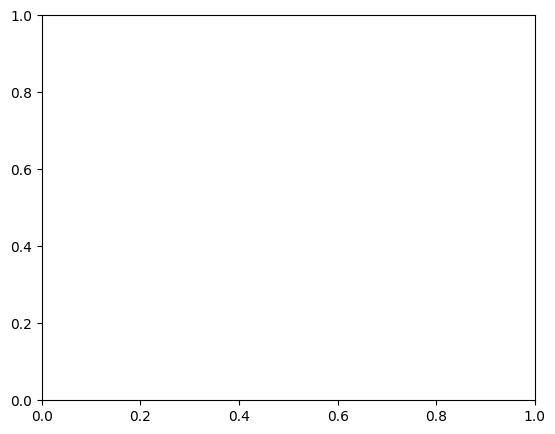

In [ ]:
# ============================================================
# 📊 PLOT TRAINING PROGRESS
# ============================================================

plt.figure(figsize=(14, 5))

# Score plot
plt.subplot(1, 2, 1)
plt.plot(scores, alpha=0.3, color='blue', label='Score per Episode')
plt.plot(avg_scores, color='orange', linewidth=2, label='100-Episode Average')
plt.axhline(y=best_score, color='red', linestyle='--', label=f'Best Score: {best_score}')
plt.axhline(y=1960, color='green', linestyle=':', alpha=0.7, label='v4 Avg (1960)')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('PRO MODE v5 Fine-Tuning Progress')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
if len(agent.losses) > 0:
    window = min(1000, len(agent.losses) // 10)
    if window > 0:
        smoothed_losses = np.convolve(agent.losses, np.ones(window)/window, mode='valid')
        plt.plot(smoothed_losses, color='purple', alpha=0.8)
    plt.xlabel('Training Step')
    plt.ylabel('Loss')
    plt.title('Training Loss (Smoothed)')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/finetune_progress_v5.png", dpi=150)
plt.show()

print(f"📊 Plot saved: {OUTPUT_DIR}/finetune_progress_v5.png")

---
# 🎬 Record Video of Fine-Tuned AI

In [ ]:
# ============================================================
# 🎬 RECORD VIDEO WITH BEST MODEL
# ============================================================

# Load best average model for recording
agent.policy_net.load_state_dict(torch.load(f"/content/drive/MyDrive/{PROJECT_NAME}/finetune_v5_flexible_position_20260117_160007/models/best_avg_model.pth", map_location=agent.device))
agent.epsilon = 0  # No exploration during recording

video_path, game_scores = record_gameplay(
    agent,
    output_path=f"/content/drive/MyDrive/{PROJECT_NAME}/finetune_v5_flexible_position_20260117_160007/videos/promode_v5_gameplay.mp4",
    num_games=20,
    fps=60,
    max_frames=20000000
)

print(f"\n🎬 Video ready: {video_path}")
print(f"\n📊 Performance Summary:")
print(f"   Scores: {game_scores}")
print(f"   Mean: {np.mean(game_scores):.1f}")
print(f"   Std: {np.std(game_scores):.1f}")
print(f"   Min: {min(game_scores)} | Max: {max(game_scores)}")
print(f"\n📈 Comparison to v4:")
print(f"   v4 Mean: 1960.0 | v5 Mean: {np.mean(game_scores):.1f}")
print(f"   v4 Std:  799.0  | v5 Std:  {np.std(game_scores):.1f}")


🎬 Recording 20 games...
pygame 2.6.1 (SDL 2.28.4, Python 3.12.12)
Hello from the pygame community. https://www.pygame.org/contribute.html
  Game 1/20...
    Score: 2000 | Kills: 20
  Game 2/20...
    Score: 2400 | Kills: 24
  Game 3/20...
    Score: 1100 | Kills: 11
  Game 4/20...
    Score: 3400 | Kills: 34
  Game 5/20...
    Score: 1000 | Kills: 10
  Game 6/20...
    Score: 200 | Kills: 2
  Game 7/20...
    Score: 1100 | Kills: 11
  Game 8/20...
    Score: 700 | Kills: 7
  Game 9/20...
    Score: 3800 | Kills: 38
  Game 10/20...
    Score: 4200 | Kills: 42
  Game 11/20...
    Score: 2600 | Kills: 26
  Game 12/20...
    Score: 2200 | Kills: 22
  Game 13/20...
    Score: 1400 | Kills: 14
  Game 14/20...
    Score: 5100 | Kills: 51
  Game 15/20...
    Score: 1000 | Kills: 10
  Game 16/20...
    Score: 1300 | Kills: 13
  Game 17/20...
    Score: 2400 | Kills: 24
  Game 18/20...
    Score: 1600 | Kills: 16
  Game 19/20...
    Score: 2300 | Kills: 23
  Game 20/20...
    Score: 1100 | Kill

✅ Video saved: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_v5_flexible_position_20260117_160007/videos/promode_v5_gameplay.mp4

🎬 Video ready: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_v5_flexible_position_20260117_160007/videos/promode_v5_gameplay.mp4

📊 Performance Summary:
   Scores: [2000, 2400, 1100, 3400, 1000, 200, 1100, 700, 3800, 4200, 2600, 2200, 1400, 5100, 1000, 1300, 2400, 1600, 2300, 1100]
   Mean: 2045.0
   Std: 1240.8
   Min: 200 | Max: 5100

📈 Comparison to v4:
   v4 Mean: 1960.0 | v5 Mean: 2045.0
   v4 Std:  799.0  | v5 Std:  1240.8


---
# 📁 Summary of Saved Files

In [ ]:
# ============================================================
# 📁 LIST ALL SAVED FILES
# ============================================================

import os

print("=" * 60)
print("📁 ALL SAVED FILES")
print("=" * 60)
print(f"\nOutput directory: {OUTPUT_DIR}\n")

for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}📂 {os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath)
        if size > 1024 * 1024:
            size_str = f"{size / (1024*1024):.1f} MB"
        elif size > 1024:
            size_str = f"{size / 1024:.1f} KB"
        else:
            size_str = f"{size} B"
        print(f"{subindent}📄 {file} ({size_str})")

print("\n" + "=" * 60)
print("✅ Fine-tuning complete!")
print("")
print("🎯 RECOMMENDED: Use best_avg_model.pth for your demo.")
print("")
print("📝 WHAT'S NEW IN v5:")
print("   - No center magnet - agent roams freely")
print("   - Surrounded detection - knows when boxed in")
print("   - Escape reward - moves when in danger")
print("   - Smarter evasion - moves away from threats")
print("=" * 60)

In [ ]:
# Optional: Disconnect runtime
from google.colab import runtime
runtime.unassign()